In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# **DATASET**

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Loan dataset.csv')

In [ ]:
df.head(2)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0


In [ ]:
df.shape

(255347, 18)

In [ ]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [ ]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop('LoanID', axis=1, inplace=True)

# **DATA VISUALIZATION**

In [ ]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

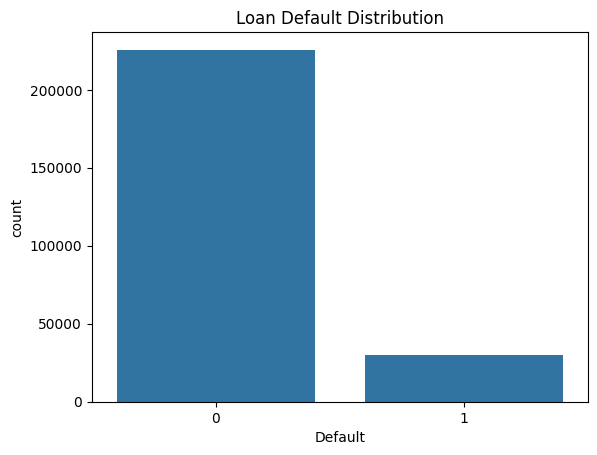

In [ ]:
sns.countplot(x='Default', data=df)
plt.title('Loan Default Distribution')
plt.show()

In [ ]:
df['Default'].value_counts()

,count
Default,
0,225694
1,29653


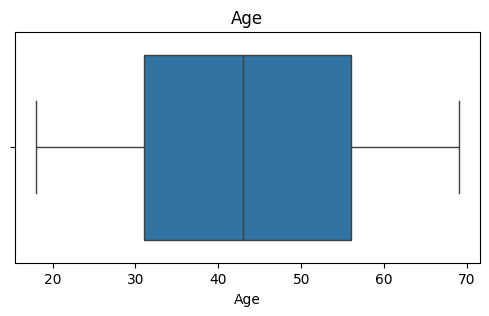

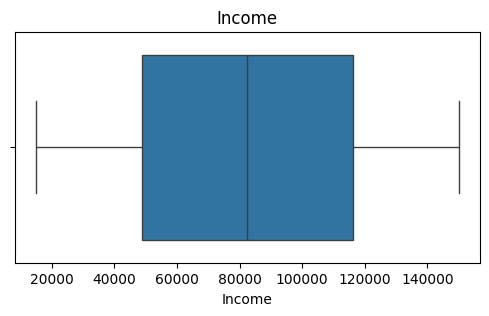

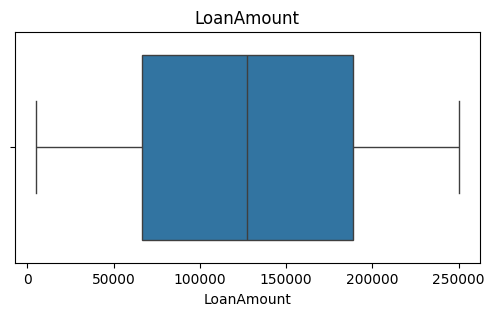

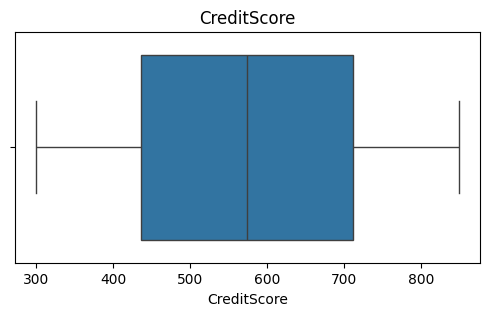

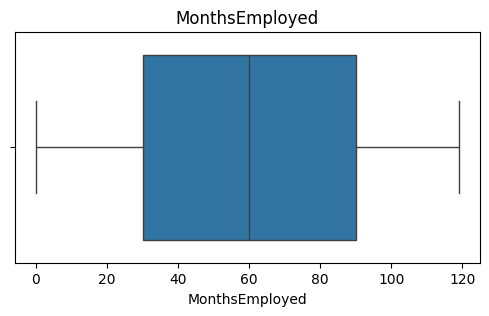

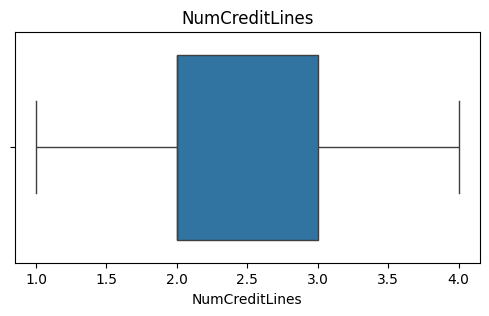

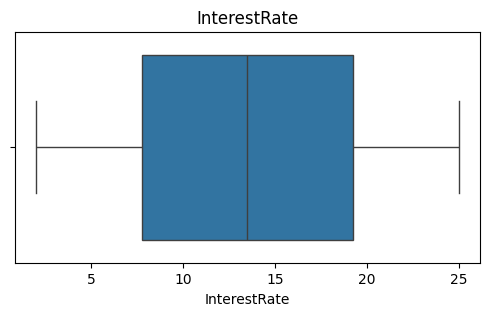

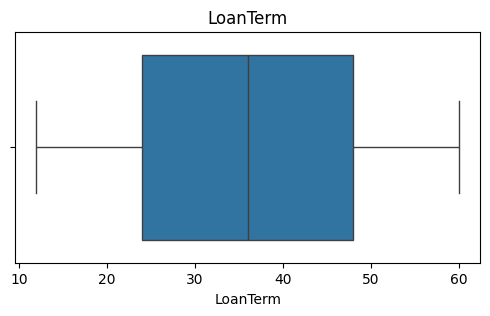

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

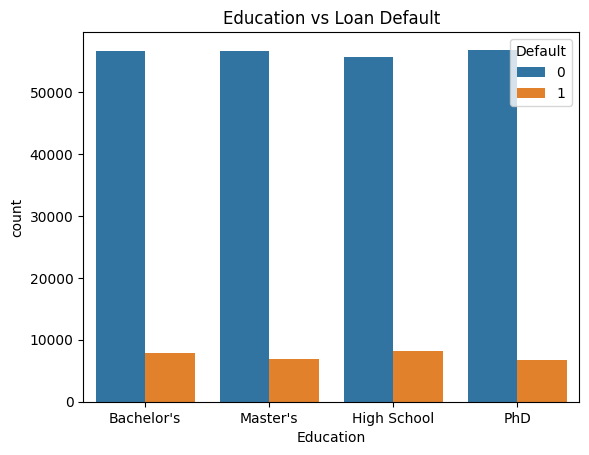

In [ ]:
sns.countplot(x='Education',
              hue='Default',
              data=df)

plt.title('Education vs Loan Default')
plt.show()

# **Encoding The Data**



In [ ]:
cat_cols = [
    'Education',
    'EmploymentType',
    'MaritalStatus',
    'LoanPurpose'
]

In [ ]:
for col in ['HasMortgage', 'HasDependents', 'HasCoSigner']:
    print(col, col in df.columns)

HasMortgage False
HasDependents False
HasCoSigner False


In [ ]:
df.columns.tolist()

['Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Default',
 'Education_High School',
 "Education_Master's",
 'Education_PhD',
 'EmploymentType_Part-time',
 'EmploymentType_Self-employed',
 'EmploymentType_Unemployed',
 'MaritalStatus_Married',
 'MaritalStatus_Single',
 'LoanPurpose_Business',
 'LoanPurpose_Education',
 'LoanPurpose_Home',
 'LoanPurpose_Other',
 'HasMortgage_Yes',
 'HasDependents_Yes',
 'HasCoSigner_Yes']

In [ ]:
df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

In [ ]:
X = df.drop('Default', axis=1)
y = df['Default']

# **TRAINING THE MODEL**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(255347, 24) (204277, 24) (51070, 24)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**PREDICTION**

In [ ]:
y_pred = rf.predict(X_test)

# **EVALUATION**

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

Accuracy: 0.8861562561190522
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.67      0.03      0.06      5900

    accuracy                           0.89     51070
   macro avg       0.78      0.51      0.50     51070
weighted avg       0.86      0.89      0.84     51070

[[45084    86]
 [ 5728   172]]


In [ ]:
train_pred = rf.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9999853140588515


In [ ]:
test_pred = rf.predict(X_test)

test_accuracy = accuracy_score(y_test, test_pred)

print("Testing Accuracy:", test_accuracy)

Testing Accuracy: 0.8861562561190522


In [ ]:
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Testing Accuracy: {test_accuracy*100:.2f}%")

Training Accuracy: 100.00%
Testing Accuracy: 88.62%


In [60]:
y_prob = rf.predict_proba(X_test)[:, 1]

In [62]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.7321439889982477


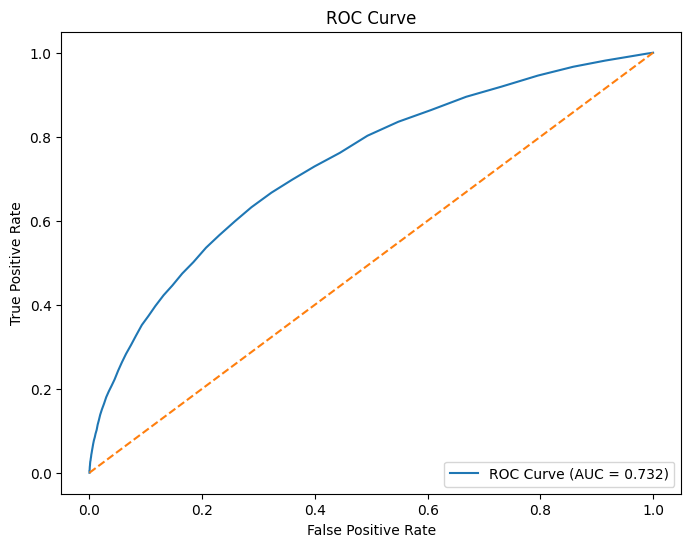

In [63]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # Random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# **TESTING THE MODEL**

In [ ]:
sample = X_test.iloc[[0]]

In [ ]:
prediction = rf.predict(sample)

print(prediction)

[0]


In [ ]:
print("Predicted:", prediction[0])
print("Actual:", y_test.iloc[0])

Predicted: 0
Actual: 0


In [ ]:
new_customer = pd.DataFrame([{
    'Age':45,
    'Income':65000,
    'LoanAmount':180000,
    'CreditScore':720,
    'MonthsEmployed':60,
    'NumCreditLines':5,
    'InterestRate':8.5,
    'LoanTerm':36,
    'DTIRatio':0.32,
    'Education_High School':0,
    'Education_Master\'s':0,
    'Education_PhD':1,
    'EmploymentType_Part-time':1,
    'EmploymentType_Self-employed':0,
    'EmploymentType_Unemployed':0,
    'MaritalStatus_Married':1,
    'MaritalStatus_Single':0,
    'LoanPurpose_Business':0,
    'LoanPurpose_Education':1,
    'LoanPurpose_Home':0,
    'LoanPurpose_Other':0,
    'HasMortgage_Yes':1,
    'HasDependents_Yes':0,
    'HasCoSigner_Yes':1
}])

prediction = rf.predict(new_customer)
print(prediction)

[0]


In [ ]:
new_customer = pd.DataFrame([{
    'Age': 22,
    'Income': 18000,
    'LoanAmount': 300000,
    'CreditScore': 320,
    'MonthsEmployed': 2,
    'NumCreditLines': 8,
    'InterestRate': 18.5,
    'LoanTerm': 60,
    'DTIRatio': 0.85,

    'Education_High School': 1,
    'Education_Master\'s': 0,
    'Education_PhD': 0,

    'EmploymentType_Part-time': 0,
    'EmploymentType_Self-employed': 0,
    'EmploymentType_Unemployed': 1,

    'MaritalStatus_Married': 0,
    'MaritalStatus_Single': 1,

    'LoanPurpose_Business': 0,
    'LoanPurpose_Education': 0,
    'LoanPurpose_Home': 0,
    'LoanPurpose_Other': 1,

    'HasMortgage_Yes': 0,
    'HasDependents_Yes': 1,
    'HasCoSigner_Yes': 0
}])

In [ ]:
prediction = rf.predict(new_customer)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Loan Default")
else:
    print("No Default")

Prediction: 1
Loan Default
